# Training & Analysing a Sparse Autoencoder on GPT-2 Small
### ILLC Lab Meeting — Multimodal Mechanistic Interpretability

**Outline**
1. Background — superposition hypothesis & SAE objective
2. Load GPT-2 Small and collect MLP-layer activations (TransformerLens)
3. Implement a clean SAE from scratch
4. Train the SAE with proper diagnostic logging
5. Training diagnostics (loss curves, L0, dead features)
6. Feature analysis — top-activating examples, vocabulary projections, cosine-sim heatmap
7. Visualisations — token-feature heatmap, UMAP of decoder directions
8. Bonus — where to go next

> **Hardware note:** Sections 2–4 take ~15 min on a Colab T4.
> A pre-trained checkpoint cell is provided so CPU-only participants can skip training.

## Section 0 — Setup & Dependencies

Dependencies: `transformer_lens`, `einops`, `datasets` (HuggingFace), `plotly`, `umap-learn`.
Everything is pip-installable; no exotic packages required.

In [ ]:

import os, sys, math, random, warnings
from pathlib import Path

# ── Suppress bitsandbytes CUDA-setup spam ─────────────────────────────────
# bitsandbytes is a transitive dependency of `transformers` (which TransformerLens
# uses internally for weight loading). It prints a long CUDA-detection report if
# libcudart.so is not on LD_LIBRARY_PATH. This env var silences it.
# It has zero effect on our SAE code — we don't use bitsandbytes directly.
os.environ["BITSANDBYTES_NOWELCOME"] = "1"

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from IPython.display import display, HTML

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU:  {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("Running on CPU — activation collection (~3 min) and training (~20 min) will be slower.")
    print("Consider reducing N_SEQUENCES to 500 and N_EPOCHS to 1 for a quick test run,")
    print("or load the pre-trained checkpoint in Section 4 to skip training entirely.")


## Section 1 — Background: What Are We Doing and Why?

### 1.1  The Superposition Hypothesis

Neural networks are trained on high-dimensional tasks, yet many believe that
the *true* structure of the world is governed by far fewer *features* — binary
or nearly-binary properties such as "is this token a verb?", "is this number
prime?", or "does this image contain a cat?".

The **superposition hypothesis** (Elhage et al. 2022) proposes that a model
with $d$ dimensions can nonetheless *approximately* represent $n \gg d$
features by assigning each feature a direction in activation space and
tolerating a small amount of *interference* between them.  The key insight is
that if features are *sparse* (active rarely and independently), the
interference is small on average, so the model can get away with it.

This means that individual neurons are **polysemantic** — they respond to
multiple unrelated concepts.  Trying to interpret a single neuron directly
produces confused, contradictory descriptions.

### 1.2  Sparse Autoencoders as a Solution

A **Sparse Autoencoder (SAE)** is a tool for *un-doing* superposition.  We
train a linear autoencoder with a much *larger* hidden layer (the
**dictionary**) so that the model has enough room to assign a dedicated
dimension to each feature.  A sparsity penalty forces the network to use as
few dictionary atoms as possible to reconstruct each activation — mirroring
the assumed sparsity of the real features.

$$\mathcal{L} = \underbrace{\|x - \hat{x}\|^2}_{\text{reconstruction}} + \lambda \underbrace{\|z\|_1}_{\text{sparsity}}$$

where

$$z = \text{ReLU}(W_{\text{enc}}(x - b_{\text{pre}}) + b_{\text{enc}}), \qquad
  \hat{x} = W_{\text{dec}}\, z + b_{\text{dec}}$$

We hook into **layer 6 MLP output** of GPT-2 Small (`d_model = 768`), a
well-studied site used in several interpretability papers.

### 1.3  SAE Architecture at a Glance

```
x ∈ ℝ^768
  │
  │  subtract b_pre (= training mean, frozen)
  ▼
W_enc @ x + b_enc            Linear(768 → 6144)
  │
  ReLU                       → z ∈ ℝ^6144_≥0   (sparse code)
  │
W_dec @ z + b_dec            Linear(6144 → 768)
  │
  ▼
x̂ ∈ ℝ^768                   (reconstruction)
```

**Two critical tricks:**
1. **Decoder column normalisation** — after each gradient step, project every
   column of $W_{\text{dec}}$ onto the unit sphere.  Without this, the model
   cheats by shrinking decoder norms and inflating encoder weights to reduce
   the L1 penalty without learning sparse structure.
2. **Encoder initialisation as transpose of decoder** — gives a sensible
   starting point where encoding and decoding are approximately inverse.

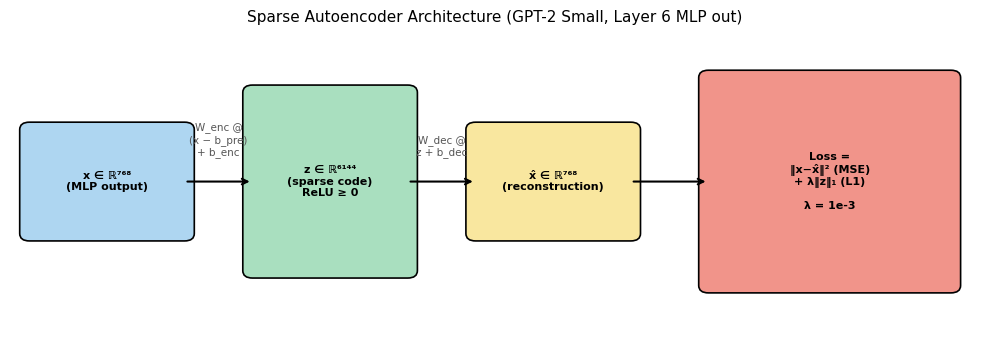

In [2]:

# Quick matplotlib architecture sketch (no external images needed)
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis("off")

def box(x, y, w, h, color, label, fontsize=9):
    rect = mpatches.FancyBboxPatch((x, y), w, h,
        boxstyle="round,pad=0.1", facecolor=color, edgecolor="black", linewidth=1.2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha="center", va="center",
            fontsize=fontsize, fontweight="bold")

def arrow(x1, x2, y=2.0):
    ax.annotate("", xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle="->", lw=1.5, color="black"))

box(0.2, 1.3, 1.6, 1.4, "#AED6F1", "x \u2208 \u211d\u2077\u2076\u2078\n(MLP output)", fontsize=8)
arrow(1.8, 2.5)
ax.text(2.15, 2.35, "W_enc @\n(x \u2212 b_pre)\n+ b_enc", ha="center", fontsize=7.5, color="#555")
box(2.5, 0.8, 1.6, 2.4, "#A9DFBF", "z \u2208 \u211d\u2076\u00b9\u2074\u2074\n(sparse code)\nReLU \u2265 0", fontsize=8)
arrow(4.1, 4.8)
ax.text(4.45, 2.35, "W_dec @\nz + b_dec", ha="center", fontsize=7.5, color="#555")
box(4.8, 1.3, 1.6, 1.4, "#F9E79F", "x\u0302 \u2208 \u211d\u2077\u2076\u2078\n(reconstruction)", fontsize=8)
arrow(6.4, 7.2)
box(7.2, 0.6, 2.5, 2.8, "#F1948A", "Loss =\n\u2016x\u2212x\u0302\u2016\u00b2 (MSE)\n+ \u03bb\u2016z\u2016\u2081 (L1)\n\n\u03bb = 1e-3", fontsize=8)

ax.set_title("Sparse Autoencoder Architecture (GPT-2 Small, Layer 6 MLP out)", fontsize=11, pad=8)
plt.tight_layout()
plt.show()


## Section 2 — Load GPT-2 Small & Collect Activations

We use **TransformerLens** to hook into `blocks.6.hook_mlp_out` — the output
of the MLP at layer 6 (residual-stream dimension, `d_model = 768`).

Text data: `stas/openwebtext-10k` — a small, freely downloadable slice of
OpenWebText (~10k documents, ~100 MB).  We process ~2000 sequences of 128
tokens, giving roughly 256 000 activation vectors.

In [ ]:

import contextlib, io

# transformer_lens triggers a bitsandbytes import (via transformers) which
# prints a CUDA-detection report when libcudart.so is not on LD_LIBRARY_PATH.
# bitsandbytes is a transitive dependency only — we never call it directly,
# and it falls back to CPU mode silently. Wrapping the import in redirects
# swallows the output without affecting any functionality.
_sink = io.StringIO()
with contextlib.redirect_stdout(_sink), contextlib.redirect_stderr(_sink):
    from transformer_lens import HookedTransformer
    from datasets import load_dataset

# Load GPT-2 small with standard TransformerLens preprocessing flags
model = HookedTransformer.from_pretrained(
    "gpt2",
    center_unembed=True,          # centre W_U so vocab projections are more interpretable
    center_writing_weights=True,  # fold LayerNorm centering into weights
    fold_ln=True,                 # fold LayerNorm scale into subsequent weights
)
model.eval()
model.to(device)

print(f"d_model    = {model.cfg.d_model}")
print(f"n_layers   = {model.cfg.n_layers}")
print(f"d_mlp      = {model.cfg.d_mlp}")
print(f"n_heads    = {model.cfg.n_heads}")
print(f"vocab_size = {model.cfg.d_vocab}")


In [ ]:
# Load text dataset
dataset = load_dataset("stas/openwebtext-10k", split="train")
print(f"Dataset: {len(dataset)} documents")
print(f"\nExample (first 300 chars):\n{dataset[0]['text'][:300]}")

In [ ]:
# ── Activation collection ──────────────────────────────────────────────────
HOOK_NAME    = "blocks.6.hook_mlp_out"   # layer 6 MLP output; shape (batch, seq, d_model)
N_SEQUENCES  = 2000                      # sequences to process
SEQ_LEN      = 128                       # tokens per sequence (truncate longer ones)
COLLECT_BS   = 16                        # batch size for forward passes

all_acts = []
n_done   = 0

model.eval()
pbar = tqdm(total=N_SEQUENCES, desc="Collecting activations")

for i in range(0, len(dataset), COLLECT_BS):
    if n_done >= N_SEQUENCES:
        break
    texts  = dataset[i : i + COLLECT_BS]["text"]
    tokens = model.to_tokens(texts, truncate=True)
    tokens = tokens[:, :SEQ_LEN].to(device)

    with torch.no_grad():
        _, cache = model.run_with_cache(tokens, names_filter=HOOK_NAME)

    acts = cache[HOOK_NAME]              # (batch, seq_len, d_model)
    all_acts.append(acts.reshape(-1, acts.shape[-1]).cpu())
    n_done += tokens.shape[0]
    pbar.update(tokens.shape[0])

pbar.close()
acts_raw = torch.cat(all_acts, dim=0)

print(f"\nActivation tensor:  {acts_raw.shape}  (n_tokens × d_model)")
print(f"Mean activation:    {acts_raw.mean():.4f}")
print(f"Mean token norm:    {acts_raw.norm(dim=-1).mean():.3f}")
print(f"Std of token norm:  {acts_raw.norm(dim=-1).std():.3f}")

In [ ]:
# ── Centring and DataLoader ────────────────────────────────────────────────
# Subtract the mean activation vector (geometric centering trick).
# This prevents dictionary atoms being wasted on the mean direction.
acts_mean    = acts_raw.mean(dim=0)          # (d_model,) — frozen, set as b_pre later
acts_centered = acts_raw - acts_mean

BATCH_SIZE_TRAIN = 4096                      # large batches → more stable SAE training
train_dataset    = TensorDataset(acts_centered)
train_loader     = DataLoader(train_dataset, batch_size=BATCH_SIZE_TRAIN,
                               shuffle=True, drop_last=True, num_workers=0)

print(f"Training DataLoader: {len(train_loader)} batches × {BATCH_SIZE_TRAIN} = "
      f"{len(train_loader) * BATCH_SIZE_TRAIN:,} tokens/epoch")
print(f"Post-centering mean: {acts_centered.mean():.2e}  (should be ~0)")

# Baseline MSE: predict the mean for every token
baseline_mse = acts_centered.pow(2).mean().item()
print(f"Baseline MSE (predict-mean): {baseline_mse:.6f}  (our target: << this)")

## Section 3 — Implementing the SAE from Scratch

A single, self-contained `SparseAutoencoder` class — every line is commented.

Key design choices are highlighted inline.

In [ ]:
class SparseAutoencoder(nn.Module):
    """
    Sparse Autoencoder with geometric centering and decoder norm constraint.

    Architecture
    ------------
    z    = ReLU( W_enc @ (x - b_pre) + b_enc )     # sparse code; z >= 0
    x_hat = W_dec @ z + b_dec                       # reconstruction

    Parameters
    ----------
    d_model   : int   — input / output dimension (768 for GPT-2 small)
    d_dict    : int   — dictionary size / hidden dimension (typically 4–32 × d_model)
    l1_coeff  : float — weight of the L1 sparsity term (λ in the loss)
    """

    def __init__(self, d_model: int, d_dict: int, l1_coeff: float = 1e-3):
        super().__init__()
        self.d_model  = d_model
        self.d_dict   = d_dict
        self.l1_coeff = l1_coeff

        # ── Pre-encoder bias ────────────────────────────────────────────────
        # Set externally to the mean of the training distribution (frozen).
        # Subtracting this before encoding means dictionary atoms can focus on
        # directions of *variation*, not on the mean activation direction.
        self.register_buffer("b_pre", torch.zeros(d_model))

        # ── Encoder ─────────────────────────────────────────────────────────
        self.W_enc = nn.Parameter(torch.empty(d_model, d_dict))
        self.b_enc = nn.Parameter(torch.zeros(d_dict))

        # ── Decoder ─────────────────────────────────────────────────────────
        self.W_dec = nn.Parameter(torch.empty(d_dict, d_model))
        self.b_dec = nn.Parameter(torch.zeros(d_model))

        self._init_weights()

    # ── Initialisation ───────────────────────────────────────────────────────
    def _init_weights(self):
        # Step 1: initialise decoder columns to random unit-norm vectors
        nn.init.normal_(self.W_dec)
        self._normalize_decoder()
        # Step 2: initialise encoder as the transpose of the decoder.
        # Intuition: if W_dec columns are the "feature directions", then W_enc
        # rows should look for those same directions in the input.
        self.W_enc.data = self.W_dec.data.T.clone()

    # ── Decoder norm constraint ───────────────────────────────────────────────
    @torch.no_grad()
    def _normalize_decoder(self):
        """
        Project every row of W_dec onto the unit sphere.

        WHY this matters
        ----------------
        Without the constraint, the optimiser can reduce the L1 penalty on z by
        shrinking ||W_dec[i]|| (making each atom smaller) while simultaneously
        increasing ||W_enc[i]|| so that the reconstruction is unchanged.
        This is a *scaling pathology* — the model has not learned sparser or
        more meaningful features; it has just redistributed scale between the
        encoder and decoder.

        Fixing ||W_dec[i]|| = 1 removes this degree of freedom, forcing the
        L1 penalty to reflect genuine sparsity.
        """
        norms = self.W_dec.norm(dim=1, keepdim=True).clamp_min(1e-8)
        self.W_dec.data = self.W_dec.data / norms

    # ── Forward pass ─────────────────────────────────────────────────────────
    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """x : (..., d_model) → z : (..., d_dict)  (non-negative sparse code)"""
        return F.relu((x - self.b_pre) @ self.W_enc + self.b_enc)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        """z : (..., d_dict) → x_hat : (..., d_model)"""
        return z @ self.W_dec + self.b_dec

    def forward(self, x: torch.Tensor) -> dict:
        """
        Returns a dict so we can log everything without re-computing.

        Keys
        ----
        z        : sparse code
        x_hat    : reconstruction
        loss     : total loss (MSE + λ * L1)
        mse_loss : reconstruction loss
        l1_loss  : mean L1 penalty
        """
        z     = self.encode(x)
        x_hat = self.decode(z)

        mse_loss = F.mse_loss(x_hat, x)
        # z >= 0 by ReLU → mean(z) == mean(|z|) == ||z||_1 / (batch * d_dict)
        l1_loss  = z.mean()
        loss     = mse_loss + self.l1_coeff * l1_loss

        return {"z": z, "x_hat": x_hat,
                "loss": loss, "mse_loss": mse_loss, "l1_loss": l1_loss}

In [ ]:
# ── Instantiate ───────────────────────────────────────────────────────────
D_MODEL  = model.cfg.d_model   # 768
D_DICT   = D_MODEL * 8         # 6144  — expansion factor 8, reasonable for a demo
L1_COEFF = 1e-3

sae = SparseAutoencoder(d_model=D_MODEL, d_dict=D_DICT, l1_coeff=L1_COEFF).to(device)

# Set pre-encoder bias to the training mean (frozen buffer, not trained)
sae.b_pre.data = acts_mean.to(device)

n_params = sum(p.numel() for p in sae.parameters() if p.requires_grad)
print(f"SAE  d_model={D_MODEL}  d_dict={D_DICT}  (expansion {D_DICT // D_MODEL}x)")
print(f"Trainable parameters: {n_params:,}")
print(f"  W_enc : {tuple(sae.W_enc.shape)}")
print(f"  b_enc : {tuple(sae.b_enc.shape)}")
print(f"  W_dec : {tuple(sae.W_dec.shape)}")
print(f"  b_dec : {tuple(sae.b_dec.shape)}")

# Verify decoder columns are unit norm after init
col_norms = sae.W_dec.norm(dim=1)
print(f"\nDecoder column norms — mean: {col_norms.mean():.4f}  std: {col_norms.std():.4f}  (should be ≈ 1.0)")

## Section 4 — Training Loop

**Hyperparameters and justification**

| Hyperparameter | Value | Why |
|---|---|---|
| Learning rate | 3e-4 | Standard Adam LR for SAEs |
| λ (L1 coeff.) | 1e-3 | Empirically gives L0 ≈ 30–100 on layer-6 MLP |
| Batch size | 4096 | Large batches improve SAE training stability |
| Epochs | 3 | Sufficient for a demo; features stabilise within epoch 1 |

**Features we track during training:**
- **Total / MSE / L1 loss** — to verify the training signal
- **Mean L0** — average number of *nonzero* features per token (out of 6144)
- **Dead features** — features that never fire in the last 100 batches; should stay low

In [ ]:
# ── Hyperparameters ───────────────────────────────────────────────────────
LR      = 3e-4
N_EPOCHS = 3
DEAD_FEATURE_WINDOW = 100   # check every N batches

optimizer = torch.optim.Adam(sae.parameters(), lr=LR)

# ── Training state ────────────────────────────────────────────────────────
logs: list[dict] = []
step = 0
# Accumulate per-feature activation counts to detect dead features
feature_activation_count = torch.zeros(D_DICT, device=device)
steps_in_window = 0

sae.train()

for epoch in range(N_EPOCHS):
    for (xb,) in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{N_EPOCHS}", leave=True):
        xb = xb.to(device)

        # ── Forward + backward ────────────────────────────────────────────
        out = sae(xb)
        out["loss"].backward()

        # Gradient clipping for stability (keeps norms in check early in training)
        torch.nn.utils.clip_grad_norm_(sae.parameters(), max_norm=1.0)

        optimizer.step()
        optimizer.zero_grad()

        # ── CRITICAL: renormalise decoder columns after every step ─────────
        sae._normalize_decoder()

        # ── Logging ───────────────────────────────────────────────────────
        with torch.no_grad():
            z = out["z"].detach()

            # L0: mean number of active features per input token
            mean_l0 = (z > 0).float().sum(dim=-1).mean().item()

            # Track which features fired in this batch
            feature_activation_count += (z > 0).float().sum(dim=0)
            steps_in_window += 1

            # Every DEAD_FEATURE_WINDOW steps, count dead features
            if steps_in_window >= DEAD_FEATURE_WINDOW:
                dead_features = int((feature_activation_count == 0).sum().item())
                if dead_features > D_DICT * 0.5:
                    print(f"  WARNING: {dead_features}/{D_DICT} dead features at step {step}")
                feature_activation_count.zero_()
                steps_in_window = 0
            else:
                dead_features = logs[-1]["dead_features"] if logs else 0

            logs.append({
                "step":         step,
                "epoch":        epoch,
                "loss":         out["loss"].item(),
                "mse_loss":     out["mse_loss"].item(),
                "l1_loss":      out["l1_loss"].item(),
                "mean_l0":      mean_l0,
                "dead_features": dead_features,
            })
        step += 1

print(f"\nTraining complete — {step} total steps")
print(f"Final total loss : {logs[-1]['loss']:.6f}")
print(f"Final MSE loss   : {logs[-1]['mse_loss']:.6f}  (baseline was {baseline_mse:.6f})")
print(f"Final mean L0    : {logs[-1]['mean_l0']:.1f} active features / token  (out of {D_DICT})")
print(f"Final dead count : {logs[-1]['dead_features']}")

In [ ]:
# ── Save checkpoint ───────────────────────────────────────────────────────
CKPT_PATH = "sae_gpt2_layer6.pt"
torch.save({
    "state_dict": sae.state_dict(),
    "d_model":    D_MODEL,
    "d_dict":     D_DICT,
    "l1_coeff":   L1_COEFF,
    "acts_mean":  acts_mean,
    "logs":       logs,
}, CKPT_PATH)
print(f"Checkpoint saved → {CKPT_PATH}")

In [ ]:
# ── LOAD PRE-TRAINED CHECKPOINT (run this cell if skipping training) ───────
# CKPT_PATH = "sae_gpt2_layer6.pt"
# ckpt      = torch.load(CKPT_PATH, map_location=device)
#
# D_MODEL   = ckpt["d_model"]
# D_DICT    = ckpt["d_dict"]
# L1_COEFF  = ckpt["l1_coeff"]
# acts_mean = ckpt["acts_mean"]
# logs      = ckpt["logs"]
#
# sae = SparseAutoencoder(d_model=D_MODEL, d_dict=D_DICT, l1_coeff=L1_COEFF).to(device)
# sae.load_state_dict(ckpt["state_dict"])
# sae.eval()
# print("Checkpoint loaded.")

## Section 5 — Training Diagnostics

Let's verify the SAE trained properly before interpreting its features.

**What to look for:**
- MSE should drop well below the predict-mean baseline
- L0 should stabilise (not keep rising — that would mean the L1 penalty is too weak)
- Dead feature count should plateau at a manageable number (< 20% of D_DICT is fine)

In [ ]:
steps_log = [d["step"]         for d in logs]
loss_log  = [d["loss"]         for d in logs]
mse_log   = [d["mse_loss"]     for d in logs]
l1_log    = [d["l1_loss"]      for d in logs]
l0_log    = [d["mean_l0"]      for d in logs]
dead_log  = [d["dead_features"] for d in logs]

# ── Loss curves ───────────────────────────────────────────────────────────
fig = make_subplots(rows=1, cols=3,
    subplot_titles=["Total Loss", "MSE Loss", "L1 Loss"])
for col, (y, name, color) in enumerate([
        (loss_log, "Total",  "#1f77b4"),
        (mse_log,  "MSE",    "#ff7f0e"),
        (l1_log,   "L1",     "#2ca02c"),
], start=1):
    fig.add_trace(go.Scatter(x=steps_log, y=y, name=name,
                              line=dict(color=color, width=1.5)),
                  row=1, col=col)

fig.update_xaxes(title_text="Step")
fig.update_layout(height=320, title_text="Training Loss Curves", showlegend=False,
                  margin=dict(t=60))
fig.show()

In [ ]:
# ── L0 and dead features over training ────────────────────────────────────
fig2 = make_subplots(rows=1, cols=2,
    subplot_titles=["Mean L0 (active features / token)",
                    "Dead features (never fired in last 100 batches)"])
fig2.add_trace(go.Scatter(x=steps_log, y=l0_log, line=dict(color="#9467bd", width=1.5),
                           name="L0"), row=1, col=1)
fig2.add_trace(go.Scatter(x=steps_log, y=dead_log, line=dict(color="#d62728", width=1.5),
                           name="Dead"), row=1, col=2)

# Add horizontal reference line: 50% dead threshold
fig2.add_hline(y=D_DICT * 0.5, line_dash="dash", line_color="red",
               annotation_text="50% dead", row=1, col=2)

fig2.update_xaxes(title_text="Step")
fig2.update_layout(height=320, title_text="Sparsity & Dead Feature Tracking",
                   showlegend=False, margin=dict(t=60))
fig2.show()

In [ ]:
# ── Feature activation frequency histogram ────────────────────────────────
# For each of the 6144 features, what fraction of inputs does it activate on?
sae.eval()
all_z_bits = []

with torch.no_grad():
    for (xb,) in DataLoader(TensorDataset(acts_centered), batch_size=4096, shuffle=False):
        z = sae.encode(xb.to(device))
        all_z_bits.append((z > 0).float().cpu())

feature_acts_all  = torch.cat(all_z_bits, dim=0)         # (n_tokens, d_dict)
feature_freqs_all = feature_acts_all.mean(dim=0).numpy()  # (d_dict,)

fig3 = go.Figure()
fig3.add_trace(go.Histogram(
    x=np.log10(feature_freqs_all + 1e-10),
    nbinsx=80,
    marker_color="#1f77b4",
))
fig3.add_vline(x=np.log10(0.01), line_dash="dash", line_color="orange",
               annotation_text="1%", annotation_position="top right")
fig3.add_vline(x=np.log10(0.1),  line_dash="dash", line_color="red",
               annotation_text="10%", annotation_position="top right")

fig3.update_layout(
    title=f"Feature activation frequency — {D_DICT} features",
    xaxis_title="log₁₀(fraction of tokens where feature fires)",
    yaxis_title="Number of features",
    bargap=0.05, height=380,
)
fig3.show()

print(f"Dead features (freq = 0)        : {(feature_freqs_all == 0).sum():4d} / {D_DICT}")
print(f"Rare  features (freq < 1%)      : {(feature_freqs_all < 0.01).sum():4d} / {D_DICT}")
print(f"Common features (freq > 10%)    : {(feature_freqs_all > 0.1).sum():4d} / {D_DICT}")

In [ ]:
# ── Reconstruction quality spot-check ─────────────────────────────────────
n_check   = 5
rng_idx   = np.random.choice(len(acts_centered), n_check, replace=False)
x_check   = acts_centered[rng_idx].to(device)

sae.eval()
with torch.no_grad():
    out_chk = sae(x_check)

x_hat_chk = out_chk["x_hat"]
z_chk     = out_chk["z"]

print(f"{'Sample':>7}  {'‖x‖':>8}  {'‖x̂‖':>8}  {'‖x−x̂‖':>10}  {'cos(x,x̂)':>10}  {'L0':>6}")
print("─" * 58)
for i in range(n_check):
    xi  = x_check[i]
    xhi = x_hat_chk[i]
    print(f"{rng_idx[i]:>7}  "
          f"{xi.norm():.4f}  "
          f"{xhi.norm():.4f}  "
          f"{(xi - xhi).norm():>10.4f}  "
          f"{F.cosine_similarity(xi.unsqueeze(0), xhi.unsqueeze(0)).item():>10.4f}  "
          f"{(z_chk[i] > 0).sum().item():>6}")

## Section 6 — Feature Analysis: What Did the SAE Learn?

Now the interpretability payoff.  For each SAE feature (a column of $W_{\text{dec}}$)
we ask:
- *Which input tokens make it fire most strongly?*  → top-activating examples
- *What vocabulary directions does it point toward?*  → decoder vocabulary projection
- *How do features relate to each other?*  → cosine similarity heatmap

**Workflow:** run a new pass over the dataset, storing per-token SAE activations
alongside the original token IDs so we can decode text.

In [ ]:
# Re-run data with token tracking (smaller subset for speed)
N_ANALYZE  = 500   # sequences — enough for meaningful analysis
ANALYZE_BS = 8

all_token_ids      = []   # list of (seq_len,) tensors
all_acts_sequences = []   # list of (seq_len, d_model) tensors (centered)
n_done = 0

model.eval()
pbar = tqdm(total=N_ANALYZE, desc="Building analysis pool")

for i in range(0, len(dataset), ANALYZE_BS):
    if n_done >= N_ANALYZE:
        break
    texts  = dataset[i : i + ANALYZE_BS]["text"]
    tokens = model.to_tokens(texts, truncate=True)
    tokens = tokens[:, :SEQ_LEN].to(device)

    with torch.no_grad():
        _, cache = model.run_with_cache(tokens, names_filter=HOOK_NAME)

    acts_seq = cache[HOOK_NAME]   # (batch, seq_len, d_model)

    for j in range(tokens.shape[0]):
        all_token_ids.append(tokens[j].cpu())
        # Centre using the same mean computed during training
        all_acts_sequences.append((acts_seq[j] - acts_mean.to(device)).cpu())

    n_done += tokens.shape[0]
    pbar.update(tokens.shape[0])

pbar.close()

# Flat token activations
acts_analysis = torch.cat([a.reshape(-1, D_MODEL) for a in all_acts_sequences], dim=0)
print(f"Analysis pool: {len(all_token_ids)} sequences | {acts_analysis.shape[0]:,} tokens")

In [ ]:
# Compute SAE sparse codes for the analysis pool
sae.eval()
z_analysis_list = []

with torch.no_grad():
    for start in range(0, acts_analysis.shape[0], 4096):
        xb = acts_analysis[start : start + 4096].to(device)
        z_analysis_list.append(sae.encode(xb).cpu())

z_analysis = torch.cat(z_analysis_list, dim=0)   # (n_tokens, d_dict)
print(f"z_analysis : {z_analysis.shape}")

# Per-feature activation frequency in analysis pool
analysis_freqs = (z_analysis > 0).float().mean(dim=0)   # (d_dict,)

# Select interesting features: top-10 common + 10 rare-but-alive
sorted_by_freq  = torch.argsort(analysis_freqs, descending=True)
common_features = sorted_by_freq[:10].tolist()

alive_mask    = analysis_freqs > 0
alive_indices = alive_mask.nonzero(as_tuple=True)[0]
perm          = torch.randperm(len(alive_indices), generator=torch.Generator().manual_seed(SEED))
rare_features = alive_indices[perm[:10]].tolist()

print(f"Common features (top-10 by freq) : {common_features}")
print(f"Rare-but-alive features (random) : {rare_features}")

In [ ]:
# ── Step 6a: Top-activating token contexts per feature ────────────────────
# Build a flat-index → (seq_idx, position_in_seq) lookup
index_map = []
for seq_idx, tids in enumerate(all_token_ids):
    for pos in range(len(tids)):
        index_map.append((seq_idx, pos))

def show_top_activating_examples(feature_idx: int, k: int = 5,
                                  context_window: int = 8) -> None:
    """Render the k text contexts where feature_idx activates most strongly."""
    scores = z_analysis[:, feature_idx]
    top_k  = torch.topk(scores, k=k)

    freq = float(analysis_freqs[feature_idx])
    parts = [f"<b>Feature {feature_idx}</b> &nbsp; "
             f"<small>freq = {freq:.4f}</small><br><br>"]

    for rank, flat_idx in enumerate(top_k.indices):
        flat_idx = int(flat_idx)
        val      = float(top_k.values[rank])
        if flat_idx >= len(index_map):
            continue
        seq_idx, pos = index_map[flat_idx]
        tids = all_token_ids[seq_idx]

        start = max(0, pos - context_window)
        end   = min(len(tids), pos + context_window + 1)

        tok_parts = []
        for tok_pos in range(start, end):
            tok_str = model.to_single_str_token(tids[tok_pos].item())
            tok_esc = (tok_str.replace("&", "&amp;")
                               .replace("<", "&lt;")
                               .replace(">", "&gt;"))
            if tok_pos == pos:
                tok_parts.append(
                    f'<mark style="background:#ffeb3b;padding:1px 3px;'
                    f'border-radius:3px;font-weight:bold">{tok_esc}</mark>')
            else:
                tok_parts.append(f'<span style="color:#555">{tok_esc}</span>')

        parts.append(f'<b>#{rank+1}</b> <small>(act={val:.3f})</small>: '
                     f'<code>{"".join(tok_parts)}</code><br>')

    display(HTML("".join(parts) + "<br>"))

# Show top examples for the 3 most common features
for fid in common_features[:3]:
    show_top_activating_examples(fid, k=5)

In [ ]:
# ── Step 6b: Feature dashboard — activation histogram + vocabulary projection ──
def feature_dashboard(feature_idx: int) -> None:
    """Show activation value distribution + top decoder vocabulary directions."""
    fig = make_subplots(rows=1, cols=2, subplot_titles=[
        f"Feature {feature_idx} — activation values (active tokens only)",
        f"Feature {feature_idx} — top vocabulary projections",
    ])

    # Left: activation histogram
    act_vals    = z_analysis[:, feature_idx].numpy()
    active_vals = act_vals[act_vals > 0]
    fig.add_trace(go.Histogram(x=active_vals, nbinsx=40,
                               marker_color="#1f77b4", name="Activations"),
                  row=1, col=1)

    # Right: decoder direction projected onto vocabulary embedding
    # W_U is (d_model, vocab) in TransformerLens
    W_dec_vec = sae.W_dec.data[feature_idx].cpu().float()  # (d_model,)
    W_U       = model.W_U.data.cpu().float()               # (d_model, vocab)
    logits    = W_dec_vec @ W_U                             # (vocab,)

    top_vocab_vals, top_vocab_idx = torch.topk(logits, k=15)
    top_tokens = [model.to_single_str_token(i.item()).strip()
                  for i in top_vocab_idx]
    top_vals   = top_vocab_vals.numpy()

    fig.add_trace(go.Bar(
        x=top_vals[::-1], y=top_tokens[::-1],
        orientation="h", marker_color="#ff7f0e", name="Vocab projection"),
        row=1, col=2)

    freq     = float(analysis_freqs[feature_idx])
    mean_act = float(active_vals.mean()) if len(active_vals) > 0 else 0

    fig.update_layout(
        height=340,
        title_text=(f"Feature {feature_idx}  |  freq={freq:.4f}  |  "
                    f"mean_act={mean_act:.3f}  |  n_active={len(active_vals):,}"),
        showlegend=False, margin=dict(t=65),
    )
    fig.show()

# Show dashboards for the 3 most common features
for fid in common_features[:3]:
    feature_dashboard(fid)

In [ ]:
# ── Step 6c: Decoder cosine-similarity heatmap (top-50 features) ──────────
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance  import pdist

top50 = sorted_by_freq[:50].numpy()
W_sub = sae.W_dec.data[top50].cpu().float().numpy()            # (50, d_model)

# Normalise rows for cosine similarity
norms = np.linalg.norm(W_sub, axis=1, keepdims=True)
W_sub_norm = W_sub / (norms + 1e-8)

cos_sim = W_sub_norm @ W_sub_norm.T                            # (50, 50)

# Ward hierarchical clustering for a more readable ordering
dists = pdist(W_sub_norm, metric="cosine")
Z     = linkage(dists, method="ward")
order = leaves_list(Z)

cos_sim_ord = cos_sim[order][:, order]
labels_ord  = [f"F{top50[i]}" for i in order]

fig = go.Figure(data=go.Heatmap(
    z=cos_sim_ord, x=labels_ord, y=labels_ord,
    colorscale="RdBu", zmin=-1, zmax=1,
    colorbar_title="cos sim",
))
fig.update_layout(
    title="Decoder direction cosine similarity — top-50 features (ward-clustered)",
    height=620, width=680, xaxis_tickangle=-45,
)
fig.show()

## Section 7 — Polished Visualisations

### 7a — Token × Feature activation heatmap

Pick a rich sentence, run it through GPT-2, collect activations, run through the SAE.
Plot: *x* = tokens, *y* = top-20 most active features, cell colour = activation strength.

This is the classic "feature dashboard" view — very compelling in presentations.

In [ ]:
DEMO_SENTENCE = (
    "The Python function returned an error because the API key "
    "had expired on January 5th, 2024."
)

tokens_demo = model.to_tokens(DEMO_SENTENCE).to(device)   # (1, seq_len)

with torch.no_grad():
    _, cache_demo = model.run_with_cache(tokens_demo, names_filter=HOOK_NAME)

acts_demo  = cache_demo[HOOK_NAME][0]                     # (seq_len, d_model)
acts_demo_c = acts_demo - acts_mean.to(device)

sae.eval()
with torch.no_grad():
    z_demo = sae.encode(acts_demo_c)                      # (seq_len, d_dict)

# Readable token strings (replace Ġ with a space prefix for display)
tok_strs = [model.to_single_str_token(t.item()) for t in tokens_demo[0]]
tok_strs_clean = [t.replace("Ġ", " ").replace("Ċ", "\n") for t in tok_strs]

# Top-20 most active features across the whole sentence
max_per_feature = z_demo.max(dim=0).values
top20_fids      = torch.topk(max_per_feature, k=20).indices.cpu().numpy()
z_heat          = z_demo[:, top20_fids].T.cpu().float().numpy()   # (20, seq_len)

fig = go.Figure(data=go.Heatmap(
    z=z_heat,
    x=tok_strs_clean,
    y=[f"F{fid}" for fid in top20_fids],
    colorscale="Viridis",
    colorbar_title="Activation",
))
fig.update_layout(
    title=(f'Token × Feature heatmap<br>'
           f'<i>"{DEMO_SENTENCE[:70]}…"</i>'),
    xaxis_title="Token",
    yaxis_title="SAE Feature",
    height=560, xaxis_tickangle=-45,
    margin=dict(t=90),
)
fig.show()

### 7b — UMAP of decoder directions

Each of the 6144 decoder weight vectors lives in ℝ⁷⁶⁸.  We project them to 2D
with UMAP and colour by log activation frequency.

- **Dense clusters** → groups of related features (e.g., punctuation, code tokens,
  named entities)
- **Isolated points** → rare or very specific features
- **Points at the periphery** → directions far from the typical activation subspace

In [ ]:
try:
    from umap import UMAP

    W_dec_all   = sae.W_dec.data.cpu().float().numpy()   # (d_dict, d_model)
    freqs_umap  = analysis_freqs.numpy()                  # (d_dict,)

    print(f"Running UMAP on {W_dec_all.shape[0]} × {W_dec_all.shape[1]} matrix …")
    reducer   = UMAP(n_neighbors=15, min_dist=0.1, random_state=SEED, verbose=False)
    embedding = reducer.fit_transform(W_dec_all)           # (d_dict, 2)
    print("Done.")

    log_freq = np.log10(freqs_umap + 1e-10)

    fig = go.Figure(data=go.Scatter(
        x=embedding[:, 0], y=embedding[:, 1],
        mode="markers",
        marker=dict(
            size=3,
            color=log_freq,
            colorscale="Viridis",
            colorbar=dict(title="log₁₀(freq)"),
            opacity=0.6,
        ),
        text=[f"Feature {i}<br>freq={freqs_umap[i]:.4f}" for i in range(D_DICT)],
        hoverinfo="text",
    ))
    fig.update_layout(
        title="UMAP of SAE decoder directions (coloured by activation frequency)",
        xaxis_title="UMAP 1", yaxis_title="UMAP 2",
        height=620, margin=dict(t=60),
    )
    fig.show()

except ImportError:
    print("umap-learn not installed — run:  pip install umap-learn")
    print("Skipping UMAP visualisation.")

### 7c (Bonus) — Sparsity–Reconstruction Pareto Frontier

Train 4 SAEs with different λ values and plot MSE vs. mean L0.
This illustrates the fundamental sparsity–reconstruction trade-off and helps
practitioners choose λ for their use case.

*(This cell is optional — it requires ~4× the training time.)*

In [ ]:
# ── Optional: λ sweep ─────────────────────────────────────────────────────
# Uncomment and run if you want to see the Pareto frontier.

# import copy
#
# lambda_values = [1e-4, 5e-4, 1e-3, 5e-3]
# pareto_points = []
#
# for lam in lambda_values:
#     print(f"\nTraining SAE with λ={lam} …")
#     sae_tmp = SparseAutoencoder(d_model=D_MODEL, d_dict=D_DICT, l1_coeff=lam).to(device)
#     sae_tmp.b_pre.data = acts_mean.to(device)
#     opt_tmp  = torch.optim.Adam(sae_tmp.parameters(), lr=LR)
#
#     sae_tmp.train()
#     for epoch in range(N_EPOCHS):
#         for (xb,) in train_loader:
#             xb = xb.to(device)
#             out = sae_tmp(xb)
#             out["loss"].backward()
#             torch.nn.utils.clip_grad_norm_(sae_tmp.parameters(), 1.0)
#             opt_tmp.step()
#             opt_tmp.zero_grad()
#             sae_tmp._normalize_decoder()
#
#     sae_tmp.eval()
#     with torch.no_grad():
#         sample_xb = acts_centered[:8192].to(device)
#         out_eval   = sae_tmp(sample_xb)
#         mse_val = out_eval["mse_loss"].item()
#         l0_val  = (out_eval["z"] > 0).float().sum(dim=-1).mean().item()
#
#     print(f"  λ={lam}  MSE={mse_val:.6f}  L0={l0_val:.1f}")
#     pareto_points.append({"lambda": lam, "mse": mse_val, "l0": l0_val})
#     del sae_tmp
#     torch.cuda.empty_cache()
#
# # Plot
# fig = go.Figure()
# fig.add_trace(go.Scatter(
#     x=[p["l0"]  for p in pareto_points],
#     y=[p["mse"] for p in pareto_points],
#     mode="markers+lines+text",
#     text=[f"λ={p['lambda']}" for p in pareto_points],
#     textposition="top center",
#     marker=dict(size=10),
# ))
# fig.update_layout(
#     title="Sparsity–Reconstruction Pareto Frontier",
#     xaxis_title="Mean L0 (active features / token)",
#     yaxis_title="MSE loss",
#     height=420,
# )
# fig.show()

## Section 8 — Where to Go Next

### Scaling up

- **[SAELens](https://github.com/jbloomAI/SAELens)** — a production-quality library
  for training large SAEs with additional tricks (auxiliary loss for dead features,
  TopK activation function, etc.).  Pre-trained SAEs for GPT-2 and Pythia are
  available out-of-the-box.
- **[Neuronpedia](https://www.neuronpedia.org/)** — an interactive dashboard for
  browsing pre-trained SAE features, seeing top-activating examples, and
  searching for interpretable features by description.

### Open research questions

1. **Feature splitting**: at larger dictionary sizes, are we finding *finer-grained*
   features or *redundant duplicates*?  How do we know when we've found the "right"
   granularity?
2. **Are SAE features real?** Causal intervention studies (e.g., activation patching
   via SAE features) are the gold standard — but results are mixed.
3. **Circuit analysis with SAE features**: can we trace information flow between
   features across layers?  See Marks et al. (2024) for early work here.
4. **Dead features and the auxiliary loss**: `aux_loss` from the SAELens codebase
   nudges dead features back to life — worth understanding.
5. **TopK SAEs (Gao et al. 2024)**: replace ReLU + L1 with a hard top-$k$ selection.
   Cleaner sparsity control, but harder to train.

### Multimodal SAEs — directly relevant to ILLC research!

The same recipe applies to vision-language models:
- Hook into the visual token representations of CLIP, LLaVA, or Flamingo
- Train an SAE on the *visual* MLP activations
- Compare SAE features across the visual and language streams — do they align?
- Probe which visual features are *causally responsible* for specific linguistic
  outputs (our lab's focus!)

Early work: Lindsey et al. (2025), "Multimodal neurons in pretrained CLIP models".

### Key papers

| Paper | What it's about |
|---|---|
| Elhage et al. (2022) — Toy Models of Superposition | The theoretical foundation |
| Cunningham et al. (2023) | First SAE paper on transformers |
| Bricken et al. (2023) — Towards Monosemanticity | Anthropic's SAE on one-layer transformer |
| Gao et al. (2024) — Scaling & Evaluating SAEs | TopK SAEs, scaling laws |
| Anthropic (2024) — Scaling Monosemanticity | SAEs on Claude Sonnet |
| Marks et al. (2024) | Circuit analysis with SAE features |